In [332]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import importlib

import geometry
import ops
import plotting

importlib.reload(geometry)
importlib.reload(ops)
importlib.reload(plotting)

<module 'plotting' from '/home/seekjim20/Python/dshape/src/plotting.py'>

## Test Case: Polygon with holes

<Axes: >

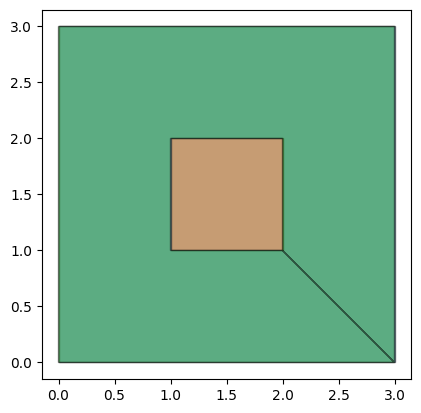

In [333]:
p1 = geometry.Rectangle(0, 0, 3, 3)
p2 = geometry.Rectangle(1, 1, 1, 1)

p3 = ops.difference(p1, p2)

fig, ax = plt.subplots()
p1.plot(ax)
p2.plot(ax)
p3.plot(ax)

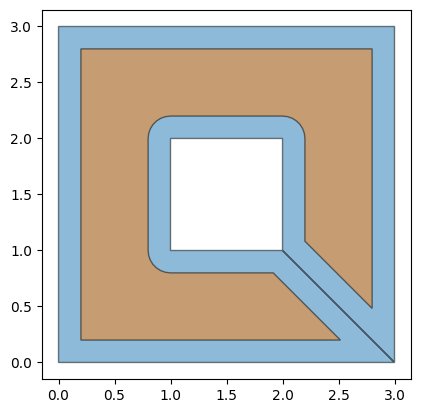

In [334]:
p4 = ops.buffer(p3, -0.2)
fig, ax = plt.subplots()
p3.plot(ax=ax)
p4.plot(ax=ax);

## Test Case: L shape.

In [335]:
def create_L_shape(origin_x=0.0, origin_y=0.0):
    vertices = jnp.array(
        [[0.0, 0.0], [1.5, 0.0], [1.5, 0.5], [1.0, 0.5], [1.0, 2.0], [0.0, 2.0]],
        dtype=jnp.float32,
    )
    vertices = vertices + jnp.array([origin_x, origin_y])
    return geometry.Polygon(vertices=vertices, count=6)

0.5650695
False


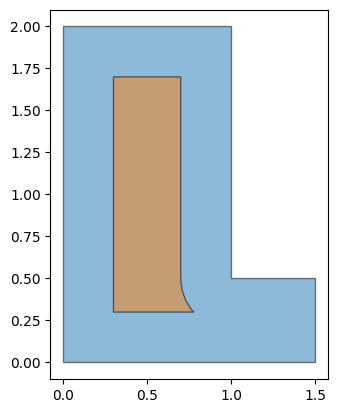

In [336]:
p1 = create_L_shape()
p2 = ops.buffer(p1, -0.3)
fig, ax = plt.subplots()
p1.plot(ax=ax)
p2.plot(ax=ax)
print(p2.area)
print(p2.self_intersect)

## Test Case: Square + Circle

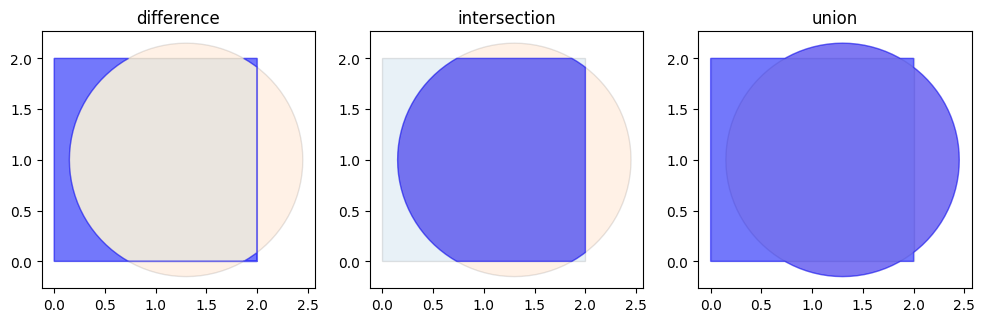

In [337]:
p1 = geometry.Rectangle(0.0, 0.0, 2.0, 2.0)
p2 = geometry.Circle(1.3, 1.0, 1.15, num_edges=100)

diff_poly = ops.difference(p1, p2)
intersection_poly = ops.intersection(p1, p2)
union_poly = ops.union(p1, p2)

_, ax = plt.subplots(figsize=(12, 4), ncols=3)

for i in range(3):
    ax[i].set_aspect('equal')
    p1.plot(ax[i], alpha=0.1)
    p2.plot(ax[i], alpha=0.1)

diff_poly.plot(ax[0], color='blue')
ax[0].set_title('difference')
intersection_poly.plot(ax[1], color='blue')
ax[1].set_title('intersection')
union_poly.plot(ax[2], color='blue')
ax[2].set_title('union')

plt.show()

## Test Case: Shrink a circle

In [338]:
p2 = geometry.Circle(0, 0, 1.15, num_edges=100)
p3 = ops.buffer(p2, -2.0)
print(f'{p3.area = }')
plotting.plot_polygons([p2, p3])

p3.area = Array(0., dtype=float32)


## Test Case: Staircase

p1.area = Array(0.5, dtype=float32)
p2.area = Array(0.87232906, dtype=float32)


<Axes: >

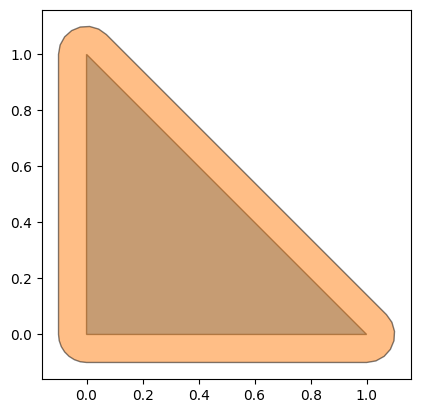

In [339]:
p1 = geometry.Polygon(
    vertices=jnp.array([
        [0.0, 0.0],
        [1.0, 0.0],
        [0.0, 1.0],
    ]),
    count=100,
)
p2 = ops.buffer(p1, 0.1)
print(f'{p1.area = }')
print(f'{p2.area = }')

fig, ax = plt.subplots()
p1.plot(ax=ax)
p2.plot(ax=ax)

In [340]:
print(p2.area)

0.87232906


## Test Case: Multiple staircases

In [401]:
p1 = geometry.Polygon(
    vertices=jnp.array([
        [0.0, 0.0],
        [1.0, 0.0],
        [0.0, 1.0],
    ]),
    count=100,
)
p1 = ops.buffer(p1, 0.08)
p2 = ops.offset(p1, 1.0, 0.0)
p3 = ops.union(p1, p2)
assert not p3.overflow
print(f'{p3.count = }')
print(f'{p3.area = }')


p3.count = Array(38, dtype=int32)
p3.area = Array(1.5580022, dtype=float32)


In [402]:
p3.vertices

Array([[ 2.0794969e+00,  8.9571718e-03],
       [ 2.0720775e+00,  3.4710720e-02],
       [ 2.0565686e+00,  5.6568556e-02],
       [ 1.0565685e+00,  1.0565685e+00],
       [ 1.0347106e+00,  1.0720775e+00],
       [ 1.0089571e+00,  1.0794970e+00],
       [ 9.8219830e-01,  1.0779942e+00],
       [ 9.5743740e-01,  1.0677379e+00],
       [ 9.3745345e-01,  1.0498792e+00],
       [ 9.2448932e-01,  1.0264223e+00],
       [ 9.2000002e-01,  1.0000000e+00],
       [ 9.2000002e-01,  1.9313705e-01],
       [ 5.6568541e-02,  1.0565685e+00],
       [ 3.4710690e-02,  1.0720775e+00],
       [ 8.9571485e-03,  1.0794970e+00],
       [-1.7801695e-02,  1.0779942e+00],
       [-4.2562574e-02,  1.0677379e+00],
       [-6.2546536e-02,  1.0498792e+00],
       [-7.5510673e-02,  1.0264223e+00],
       [-7.9999998e-02,  1.0000000e+00],
       [-7.9999998e-02,  6.9938220e-09],
       [-7.7994227e-02, -1.7801674e-02],
       [-7.2077513e-02, -3.4710687e-02],
       [-6.2546521e-02, -4.9879178e-02],
       [-4.98791

<Axes: >

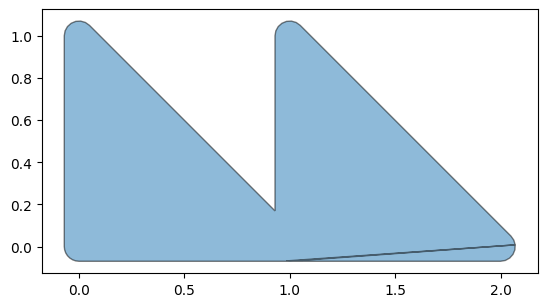

In [ ]:
fig, ax = plt.subplots()
p3.plot(ax=ax)

In [264]:
@jax.jit
def func(distance):
    p_mid = ops.buffer(p1, distance)
    p_left = ops.offset(p_mid, -1.0, 0.0)
    p_right = ops.offset(p_mid, 1.0, 0.0)
    p_total = ops.union(p_left, p_right)
    return p_total.area

grad = jax.jit(jax.grad(func))

In [269]:
(func(0.1) - func(0.1 - 1e-3)) / 1e-3, grad(0.1)

(Array(5.594849, dtype=float32),
 Array(5.599313, dtype=float32, weak_type=True))